In this part, we want to analyse the data we generated. 

# imports

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# file paths

In [30]:
# these are the files you just generated using the napari interface. 
cy3_spots = '../cy3_spots.pkl'
cy5_spots = '../cy5_spots.pkl'
cell_labels = '../segmentation.pkl'

In [31]:
cells = pd.read_pickle(cell_labels)

In [32]:
cells

,cell_label
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


# cy 5 channel

In [33]:
cy5_spots_data = pd.read_pickle(cy5_spots)


In [34]:
#inspect data 
cy5_spots_data.head()

,row,column,cell_id,spot_intensities,nuclear_intensity
0,380,140,14,5811,32817
1,570,382,28,5494,37615
2,342,475,11,4435,28679
3,373,438,15,4939,37189
4,686,258,32,3791,33740


In [35]:
# plot histograms of spots per cell:

### cy 5 - transcripts per cell 

/tmp/ipykernel_30948/4231196309.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cy5_counts = (cy5_spots_data.groupby('cell_id').apply(lambda x: len(x)).to_frame()


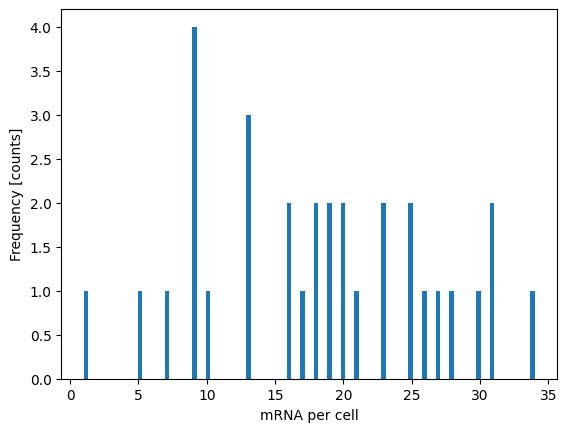

In [36]:
cy5_counts = (cy5_spots_data.groupby('cell_id').apply(lambda x: len(x)).to_frame()
).merge(cells, left_index=True, right_on='cell_label', how='outer').fillna(value=0)

cy5_counts.columns = ['counts','cell_label']

cy5_counts['counts'].plot(kind='hist', bins=100)

plt.xlabel('mRNA per cell')
plt.ylabel('Frequency [counts]')
# adjust bin number to better visualise distribution

plt.savefig('../../Results/notebooks/cy5_transcripts_per_cell.png')

### cy5 - mRNAs per transcription site

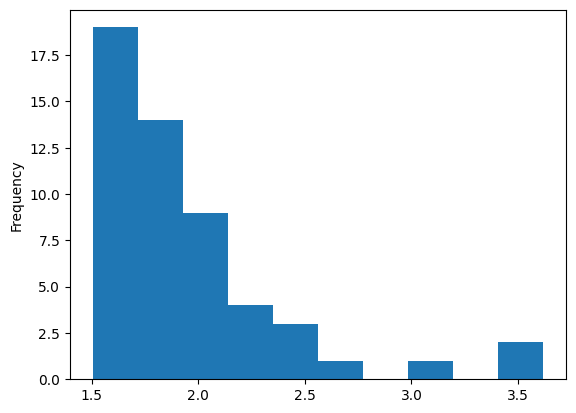

In [ ]:
intensities = cy5_spots_data['spot_intensities']
mean_intensity = np.mean(intensities)
transcription_site_threshold = 1.5 * mean_intensity
cy5_spots_data['transcription_site_candidate'] = intensities > transcription_site_threshold

# check the max projection of the DAPI channel for appropriate intensities
# find appropriate values in napari
nuclear_intensity_threshold = 0.8

cy5_spots_data['nuclear_localisation'] = cy5_spots_data['nuclear_intensity'] > nuclear_intensity_threshold
#Checks if the candidate is also located in the nucleus?
cy5_spots_data['transcription_sites'] = (
    cy5_spots_data['transcription_site_candidate'] & cy5_spots_data['nuclear_localisation'])

(cy5_spots_data[cy5_spots_data['transcription_sites']]['spot_intensities']/mean_intensity).plot(kind='hist')

plt.savefig('../../Results/notebooks/cy5_mRNAs_per_transcription_site.png')

# cy 3 channel

In [38]:
cy3_spots_data = pd.read_pickle(cy3_spots)

In [39]:
#inspect data 
cy3_spots_data.head()

,row,column,cell_id,spot_intensities,nuclear_intensity
0,292,342,6,10721,9186
1,297,349,6,10155,8299
2,155,321,4,10264,5466
3,82,80,1,10153,5988
4,134,375,3,9807,21325


### cy 3 - transcripts per cell 

/tmp/ipykernel_30948/284139411.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cy3_counts = (cy3_spots_data.groupby('cell_id').apply(lambda x: len(x)).to_frame()


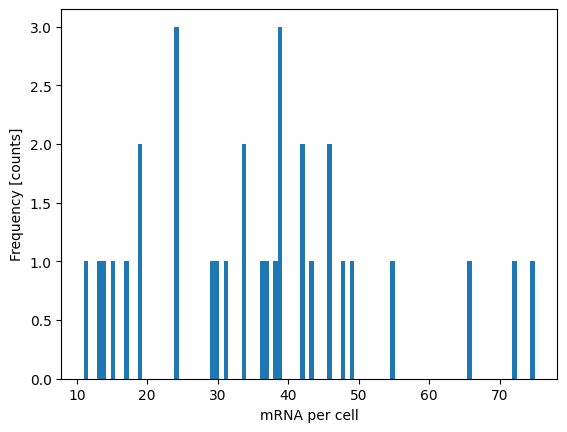

In [40]:
cy3_counts = (cy3_spots_data.groupby('cell_id').apply(lambda x: len(x)).to_frame()
).merge(cells, left_index=True, right_on='cell_label', how='outer').fillna(value=0)

cy3_counts.columns = ['counts','cell_label']

cy3_counts['counts'].plot(kind='hist', bins=100)

plt.xlabel('mRNA per cell')
plt.ylabel('Frequency [counts]')
# adjust bin number to better visualise distribution

plt.savefig('../../Results/notebooks/cy3_transcripts_per_cell.png')

### cy3 - mRNAs per transcription site

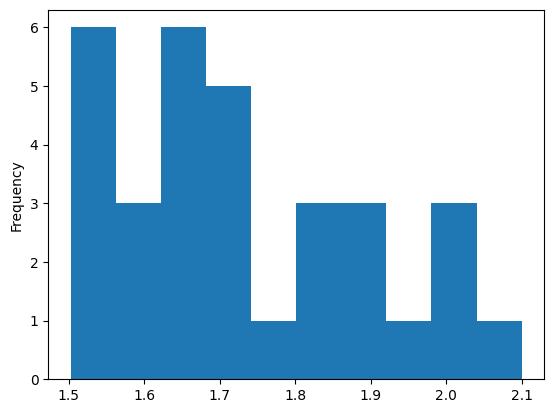

In [41]:
intensities = cy3_spots_data['spot_intensities']
mean_intensity = np.mean(intensities)
transcription_site_threshold = 1.5 * mean_intensity
cy3_spots_data['transcription_site_candidate'] = intensities > transcription_site_threshold

# check the max proejction of the DAPI channel for appropriate intensities
# find appropriate values in napari
nuclear_intensity_threshold = 0.8

cy3_spots_data['nuclear_localisation'] = cy3_spots_data['nuclear_intensity'] > nuclear_intensity_threshold
cy3_spots_data['transcription_sites'] = (
    cy3_spots_data['transcription_site_candidate'] & cy3_spots_data['nuclear_localisation'])

(cy3_spots_data[cy3_spots_data['transcription_sites']]['spot_intensities']/mean_intensity).plot(kind='hist')

plt.savefig('../../Results/notebooks/cy3_mRNAs_per_transcription_site.png')